# Maze generation

### Recursive Backtracking
En este cuaderno desarrollaremos laberitnos por medio del algoritmo Recursive Backtracking


In [1]:
pip install matplotlib numpy


Como aclaración imaginemos que la idea del algoritmo es a partir de un laberinto solido, donde no hay caminos, ir construyendo los caminos.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random

Primero definimos los posibles movimientos.
Si notamos definimos que se mueva 2 celdas, esto es porque el algoritmo se enfoca saber si mi celda destino es una celda viable, mientras que la celda intermedia, funciona como celda del camino.

In [49]:
MOV = [(-2, 0), (2, 0), (0, -2), (0, 2)]

Esta funcion se encarga de revisar que la posible celda correspondiente al nuevo camino (x,y); no se salga de los límites del laberinto, que el destino no sea ya camino; y por último revisamos que las celdas vecinas de nuestro destino esten aisladas, para no formar ciclos

In [50]:

def es_valido(x, y, maze):
    if not (0 < x < maze.shape[0] - 1 and 0 < y < maze.shape[1] - 1):
        return False
    if maze[x][y] != 1:
        return False

    vecinos = [(x-1,y), (x+1,y), (x,y-1), (x,y+1)]
    muros_cerca = sum(maze[i][j] == 1 for i,j in vecinos if 0 <= i < maze.shape[0] and 0 <= j < maze.shape[1])
    return muros_cerca >= 3



```python title:Backtrack

   # recibe celda destino para volver camino
    def backtrack(x, y):
        maze[x][y] = 0
        #guardamos posibles movimientos
        dirs = MOV[:]
        #las opciones de donde nos moveremos son aleatorias
        random.shuffle(dirs)
        # las opciones ordenadas aleatoriamente las iteramos (posibles caminos)
        for dx, dy in dirs:
          # calculo celda destino
            nx, ny = x + dx, y + dy
            # si es valido abrimos el camino y usamos recursividad
            if es_valido(nx, ny, maze):
                maze[x + dx//2][y + dy//2] = 0  # abre camino
                backtrack(nx, ny)


```


In [51]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def mostrar_laberinto(maze):
    # Definir colores mapa
    cmap = mcolors.ListedColormap(['white', 'black', 'green', 'red'])


    # Mostrar el laberinto
    plt.figure(figsize=(8, 8))
    plt.imshow(maze, cmap=cmap)
    plt.axis('off')
    plt.show()


El laberinto tiene que tener un número de celda impara para que funcione. Y creamos el bloque de solo 1s. Finalmente iniciamos desde la posición (1,1) dentro del laberinto

In [52]:


def generar_laberinto_backtracker(n, m):
    if n % 2 == 0: n += 1
    if m % 2 == 0: m += 1

    maze = np.ones((n, m), dtype=int)  # 1 = muro, 0 = camino

    def backtrack(x, y):
        maze[x][y] = 0
        dirs = MOV[:]
        random.shuffle(dirs)
        for dx, dy in dirs:
            nx, ny = x + dx, y + dy
            if es_valido(nx, ny, maze):
                maze[x + dx//2][y + dy//2] = 0  # abre camino
                backtrack(nx, ny)

    start_x, start_y = 1, 1
    backtrack(start_x, start_y)
    return maze


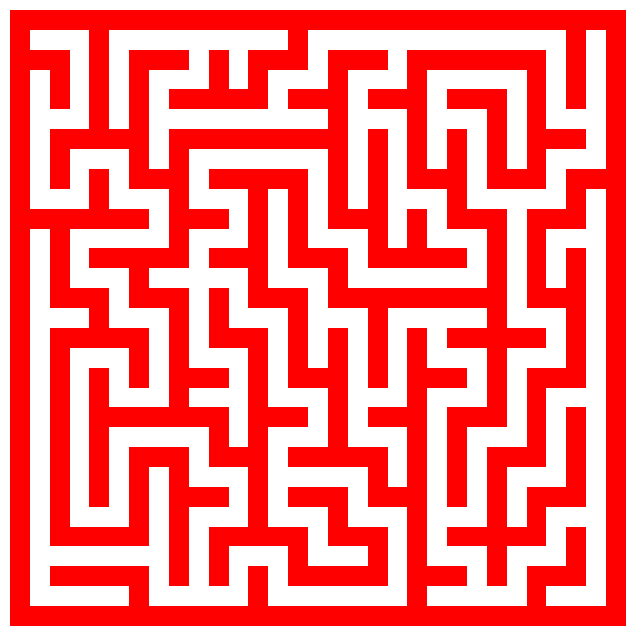

In [56]:

maze = generar_laberinto_backtracker(31, 31)
mostrar_laberinto(maze)

Una vez creamos el laberinto vamos a colocar entrada y salida si queremos o usamos la salida directamente en un laberinto cerrado.
Colocamos un 2 de entrada y un 3 de salida. Para poder usarlo en algoritmo

In [57]:

def agregar_entrada_salida_aleatoria(maze):
    n, m = maze.shape


    posibles_entradas = [i for i in range(1, n-1) if maze[i][1] == 0 and i % 2 == 1]
    fila_entrada = random.choice(posibles_entradas)
    maze[fila_entrada][0] = 2  # ENTRADA

    posibles_salidas = [i for i in range(1, n-1) if maze[i][m-2] == 0 and i % 2 == 1]
    fila_salida = random.choice(posibles_salidas)
    maze[fila_salida][m-1] = 3  # SALIDA

    return maze



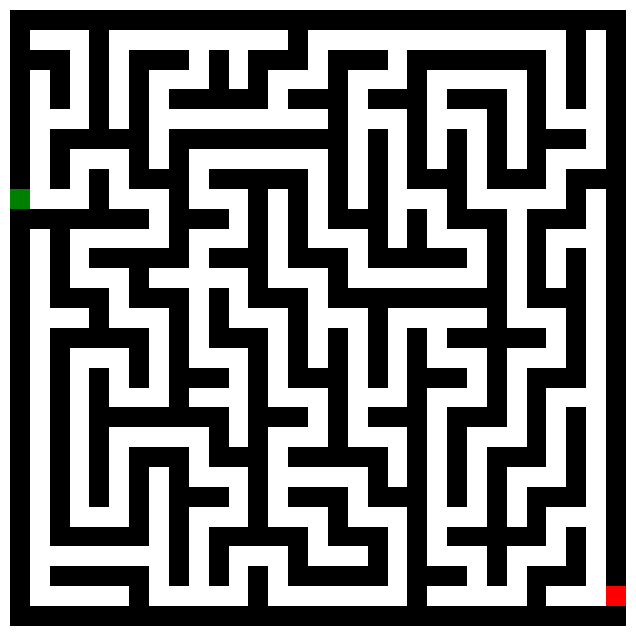

In [58]:
mostrar_laberinto(agregar_entrada_salida_aleatoria(maze))

:D